In [1]:
!pip install pyspark

In [2]:
!pip install kaggle

In [3]:
import os
from google.colab import userdata
os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_TOKEN')

In [4]:
import pyspark

In [5]:
!kaggle datasets download ahmettezcantekin/beginner-datasets


Dataset URL: https://www.kaggle.com/datasets/ahmettezcantekin/beginner-datasets
License(s): CC0-1.0
  0% 0.00/13.1M [00:00<?, ?B/s]
100% 13.1M/13.1M [00:00<00:00, 245MB/s]


In [6]:
import zipfile

with zipfile.ZipFile("/content/beginner-datasets.zip", "r") as files:
    files.extract("beginner_datasets/insurance.csv", path="datasets")

In [7]:
from pyspark.sql import SparkSession

In [8]:
spark=SparkSession.builder.appName('LinearRegression').getOrCreate()

In [9]:
spark

In [10]:
df=spark.read.option('header','true').csv('/content/datasets/beginner_datasets/insurance.csv',inferSchema=True)

In [11]:
type(df)

pyspark.sql.classic.dataframe.DataFrame

In [12]:
df.printSchema()

root
 |-- age: integer (nullable = true)
 |-- sex: string (nullable = true)
 |-- bmi: double (nullable = true)
 |-- children: integer (nullable = true)
 |-- smoker: string (nullable = true)
 |-- region: string (nullable = true)
 |-- charges: double (nullable = true)



In [13]:
df.show(5)

+---+------+------+--------+------+---------+-----------+
|age|   sex|   bmi|children|smoker|   region|    charges|
+---+------+------+--------+------+---------+-----------+
| 19|female|  27.9|       0|   yes|southwest|  16884.924|
| 18|  male| 33.77|       1|    no|southeast|  1725.5523|
| 28|  male|  33.0|       3|    no|southeast|   4449.462|
| 33|  male|22.705|       0|    no|northwest|21984.47061|
| 32|  male| 28.88|       0|    no|northwest|  3866.8552|
+---+------+------+--------+------+---------+-----------+
only showing top 5 rows


In [14]:
df.describe().show()

+-------+------------------+------+------------------+-----------------+------+---------+------------------+
|summary|               age|   sex|               bmi|         children|smoker|   region|           charges|
+-------+------------------+------+------------------+-----------------+------+---------+------------------+
|  count|              1338|  1338|              1338|             1338|  1338|     1338|              1338|
|   mean| 39.20702541106129|  NULL|30.663396860986538|  1.0949177877429|  NULL|     NULL|13270.422265141257|
| stddev|14.049960379216147|  NULL| 6.098186911679012|1.205492739781914|  NULL|     NULL|12110.011236693992|
|    min|                18|female|             15.96|                0|    no|northeast|         1121.8739|
|    max|                64|  male|             53.13|                5|   yes|southwest|       63770.42801|
+-------+------------------+------+------------------+-----------------+------+---------+------------------+



In [15]:
from pyspark.sql.functions import col, sum, when, isnull, isnan


In [16]:

df.select([
    sum(when(isnull(c), 1).otherwise(0)).alias(c)
    for c in df.columns
]).show()

+---+---+---+--------+------+------+-------+
|age|sex|bmi|children|smoker|region|charges|
+---+---+---+--------+------+------+-------+
|  0|  0|  0|       0|     0|     0|      0|
+---+---+---+--------+------+------+-------+



In [17]:
df=df.drop_duplicates()

In [18]:
from pyspark.sql.functions import lower, trim


In [19]:
df=df.withColumn("gender",lower(trim(df["sex"])))
df = df.withColumn("smoker", lower(trim(df["smoker"])))
df = df.withColumn("region", lower(trim(df["region"])))

In [20]:
df=df.drop("sex")

In [21]:
df.describe().show()

+-------+------------------+------------------+------------------+------+---------+------------------+------+
|summary|               age|               bmi|          children|smoker|   region|           charges|gender|
+-------+------------------+------------------+------------------+------+---------+------------------+------+
|  count|              1337|              1337|              1337|  1337|     1337|              1337|  1337|
|   mean|39.222139117427076|30.663451757666415|1.0957367240089753|  NULL|     NULL|13279.121486655955|  NULL|
| stddev|14.044332734156432| 6.100468409615799| 1.205571428641218|  NULL|     NULL|12110.359656344162|  NULL|
|    min|                18|             15.96|                 0|    no|northeast|         1121.8739|female|
|    max|                64|             53.13|                 5|   yes|southwest|       63770.42801|  male|
+-------+------------------+------------------+------------------+------+---------+------------------+------+



In [22]:
from pyspark.ml.regression import LinearRegression
train_data,test_data=df.randomSplit([0.8,0.2],42)

In [23]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
gender_indexer = StringIndexer(inputCol="gender", outputCol="gender_index")
smoker_indexer = StringIndexer(inputCol="smoker", outputCol="smoker_index")
region_indexer = StringIndexer(inputCol="region", outputCol="region_index")


In [24]:
from pyspark.ml.feature import OneHotEncoder

encoder = OneHotEncoder(
    inputCols=["gender_index","smoker_index","region_index"],
    outputCols=["gender_vec","smoker_vec","region_vec"]
)

In [25]:
assembler=VectorAssembler(
    inputCols=[
        "age",
        "bmi",
        "children",
        "gender_vec",
        "smoker_vec",
        "region_vec"
            ],
    outputCol="features"
)

In [26]:
from pyspark.ml import Pipeline


In [27]:
pipeline=Pipeline(stages=[
  gender_indexer,
    smoker_indexer,
    region_indexer,
    encoder,
    assembler

])

In [28]:
model=pipeline.fit(train_data)

In [29]:
clean_data=model.transform(train_data)

In [30]:
clean_data.show()

+---+------+--------+------+---------+-----------------+------+------------+------------+------------+-------------+-------------+-------------+--------------------+
|age|   bmi|children|smoker|   region|          charges|gender|gender_index|smoker_index|region_index|   gender_vec|   smoker_vec|   region_vec|            features|
+---+------+--------+------+---------+-----------------+------+------------+------------+------------+-------------+-------------+-------------+--------------------+
| 18| 15.96|       0|    no|northeast|        1694.7964|  male|         0.0|         0.0|         2.0|(1,[0],[1.0])|(1,[0],[1.0])|(3,[2],[1.0])|[18.0,15.96,0.0,1...|
| 18| 17.29|       2|   yes|northeast|       12829.4551|  male|         0.0|         1.0|         2.0|(1,[0],[1.0])|    (1,[],[])|(3,[2],[1.0])|[18.0,17.29,2.0,1...|
| 18| 21.47|       0|    no|northeast|        1702.4553|  male|         0.0|         0.0|         2.0|(1,[0],[1.0])|(1,[0],[1.0])|(3,[2],[1.0])|[18.0,21.47,0.0,1...|
| 18

In [31]:
cleaned_train_dataset=clean_data.select('features','charges')

In [32]:
clean_test=model.transform(test_data)

In [33]:
clean_test_dataset=clean_test.select('features','charges')

In [34]:
clean_test_dataset.show(5)

+--------------------+-----------+
|            features|    charges|
+--------------------+-----------+
|(8,[0,1,4,5],[18....|  1607.5101|
|[18.0,21.78,2.0,1...|11884.04858|
|[18.0,23.085,0.0,...| 1704.70015|
|(8,[0,1,4,7],[18....|  2196.4732|
|(8,[0,1,4,5],[18....|  1615.7667|
+--------------------+-----------+
only showing top 5 rows


In [35]:
from pyspark.ml.feature import StandardScaler

In [36]:
scaler=StandardScaler(
    inputCol="features",
    outputCol="scaled_features"
)

In [37]:
scaler_model=scaler.fit(cleaned_train_dataset)

In [38]:
cleaned_train_dataset=scaler_model.transform(cleaned_train_dataset)

In [39]:
cleaned_train_dataset.show(5)

+--------------------+-----------+--------------------+
|            features|    charges|     scaled_features|
+--------------------+-----------+--------------------+
|[18.0,15.96,0.0,1...|  1694.7964|[1.27948473174104...|
|[18.0,17.29,2.0,1...| 12829.4551|[1.27948473174104...|
|[18.0,21.47,0.0,1...|  1702.4553|[1.27948473174104...|
|(8,[0,1,3,7],[18....|13747.87235|(8,[0,1,3,7],[1.2...|
|(8,[0,1,7],[18.0,...| 14283.4594|(8,[0,1,7],[1.279...|
+--------------------+-----------+--------------------+
only showing top 5 rows


In [40]:
clean_test_dataset.show()

+--------------------+------------------+
|            features|           charges|
+--------------------+------------------+
|(8,[0,1,4,5],[18....|         1607.5101|
|[18.0,21.78,2.0,1...|       11884.04858|
|[18.0,23.085,0.0,...|        1704.70015|
|(8,[0,1,4,7],[18....|         2196.4732|
|(8,[0,1,4,5],[18....|         1615.7667|
|[18.0,28.31,1.0,1...|11272.331390000001|
|(8,[0,1,4,7],[18....|        21344.8467|
|[18.0,31.35,4.0,0...|         4561.1885|
|(8,[0,1,4,5],[18....|       11482.63485|
|[18.0,34.1,0.0,1....|          1137.011|
|[18.0,34.43,0.0,1...|         1137.4697|
|(8,[0,1,4,7],[18....|        2211.13075|
|(8,[0,1,5],[18.0,...|        36149.4835|
|(8,[0,1,3,5],[18....|        36307.7983|
|(8,[0,1,4,7],[18....|        2217.46915|
|(8,[0,1,3,4],[19....|         1621.3402|
|[19.0,20.7,0.0,1....|          1242.816|
|(8,[0,1],[19.0,28...|        17468.9839|
|(8,[0,1,4],[19.0,...|        2128.43105|
|(8,[0,1,3],[19.0,...|        33750.2918|
+--------------------+------------

In [41]:
cleaned_test_dataset=scaler_model.transform(clean_test_dataset)

In [42]:
cleaned_test_dataset.show()

+--------------------+------------------+--------------------+
|            features|           charges|     scaled_features|
+--------------------+------------------+--------------------+
|(8,[0,1,4,5],[18....|         1607.5101|(8,[0,1,4,5],[1.2...|
|[18.0,21.78,2.0,1...|       11884.04858|[1.27948473174104...|
|[18.0,23.085,0.0,...|        1704.70015|[1.27948473174104...|
|(8,[0,1,4,7],[18....|         2196.4732|(8,[0,1,4,7],[1.2...|
|(8,[0,1,4,5],[18....|         1615.7667|(8,[0,1,4,5],[1.2...|
|[18.0,28.31,1.0,1...|11272.331390000001|[1.27948473174104...|
|(8,[0,1,4,7],[18....|        21344.8467|(8,[0,1,4,7],[1.2...|
|[18.0,31.35,4.0,0...|         4561.1885|[1.27948473174104...|
|(8,[0,1,4,5],[18....|       11482.63485|(8,[0,1,4,5],[1.2...|
|[18.0,34.1,0.0,1....|          1137.011|[1.27948473174104...|
|[18.0,34.43,0.0,1...|         1137.4697|[1.27948473174104...|
|(8,[0,1,4,7],[18....|        2211.13075|(8,[0,1,4,7],[1.2...|
|(8,[0,1,5],[18.0,...|        36149.4835|(8,[0,1,5],[1.

In [43]:
regressor=LinearRegression(featuresCol='scaled_features',labelCol='charges')

In [44]:
lr_model=regressor.fit(cleaned_train_dataset)

In [45]:
lr_model.coefficients

DenseVector([3777.5239, 2016.8429, 582.0247, -153.3957, -9579.1712, -334.165, -196.6232, 109.1189])

In [46]:
evaluate=lr_model.evaluate(cleaned_test_dataset)

In [47]:
evaluate.predictions.show(10)

+--------------------+------------------+--------------------+-------------------+
|            features|           charges|     scaled_features|         prediction|
+--------------------+------------------+--------------------+-------------------+
|(8,[0,1,4,5],[18....|         1607.5101|(8,[0,1,4,5],[1.2...|-1384.6530840811647|
|[18.0,21.78,2.0,1...|       11884.04858|[1.27948473174104...| -397.8550447023372|
|[18.0,23.085,0.0,...|        1704.70015|[1.27948473174104...|  67.30667005337273|
|(8,[0,1,4,7],[18....|         2196.4732|(8,[0,1,4,7],[1.2...| 1029.7523777573879|
|(8,[0,1,4,5],[18....|         1615.7667|(8,[0,1,4,5],[1.2...|  567.9153371619104|
|[18.0,28.31,1.0,1...|11272.331390000001|[1.27948473174104...| 2268.8581113203436|
|(8,[0,1,4,7],[18....|        21344.8467|(8,[0,1,4,7],[1.2...|  2684.833522699959|
|[18.0,31.35,4.0,0...|         4561.1885|[1.27948473174104...|  5026.854438652513|
|(8,[0,1,4,5],[18....|       11482.63485|(8,[0,1,4,5],[1.2...| 2918.2291775470912|
|[18

In [48]:
evaluate.rootMeanSquaredError

5560.664095604662

In [49]:
plot_df = evaluate.predictions.select("charges", "prediction")

In [50]:
plot_df=plot_df.toPandas()

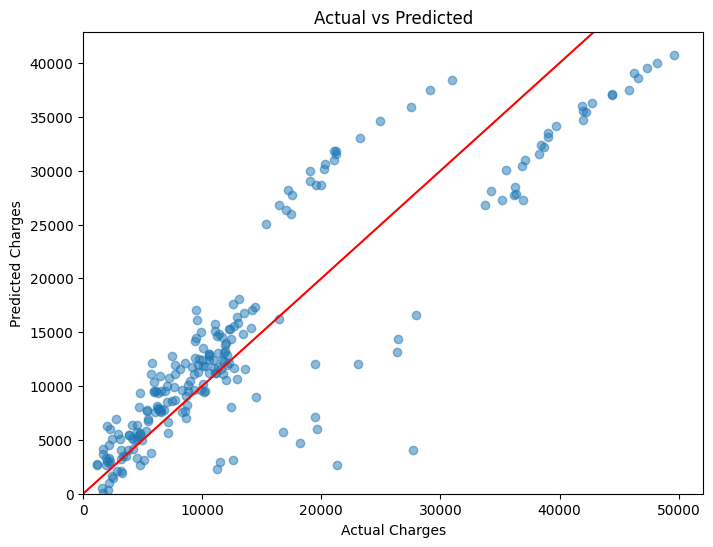

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(plot_df["charges"], plot_df["prediction"], alpha=0.5)

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.axline((0,0),slope=1,color="red")
plt.title("Actual vs Predicted")
plt.xlim(xmin=0.0)
plt.ylim(ymin=0.0)

plt.show()

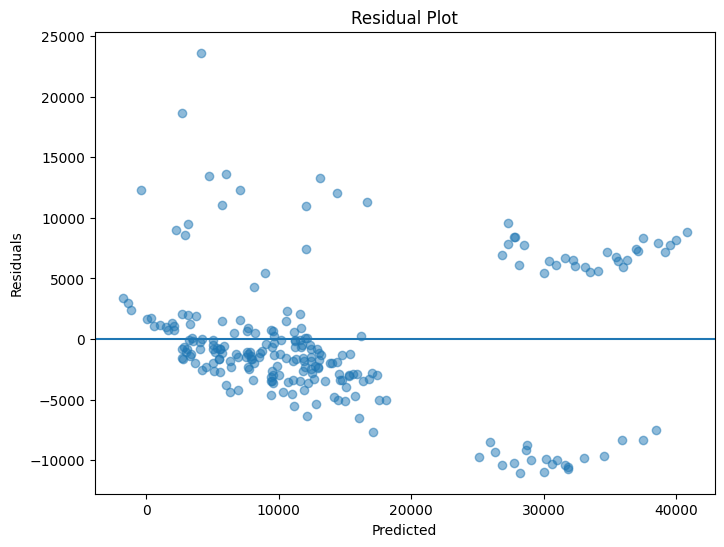

In [52]:
plot_df["residual"] = plot_df["charges"] - plot_df["prediction"]

plt.figure(figsize=(8,6))
plt.scatter(plot_df["prediction"], plot_df["residual"], alpha=0.5)

plt.axhline(0)
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

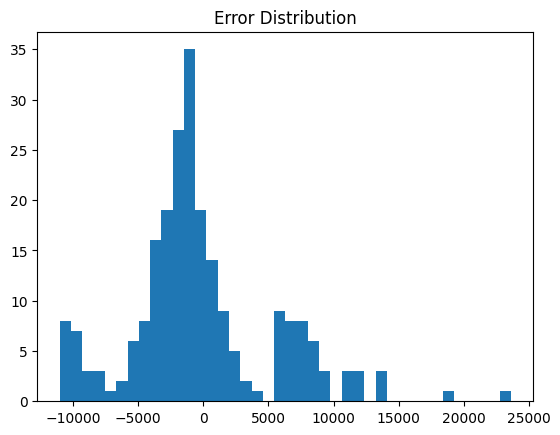

In [53]:
plt.hist(plot_df["residual"], bins=40)
plt.title("Error Distribution")
plt.show()

### Random Forest Regressor


In [54]:
from pyspark.ml.regression import RandomForestRegressor

rf = RandomForestRegressor(
    featuresCol="features",
    labelCol="charges",
    numTrees=150
)

rf_model = rf.fit(cleaned_train_dataset)

In [55]:
rf_model

RandomForestRegressionModel: uid=RandomForestRegressor_a1a7ddc817e5, numTrees=150, numFeatures=8

In [56]:
evaluation=rf_model.transform(cleaned_test_dataset)

In [57]:
evaluation.show()

+--------------------+------------------+--------------------+------------------+
|            features|           charges|     scaled_features|        prediction|
+--------------------+------------------+--------------------+------------------+
|(8,[0,1,4,5],[18....|         1607.5101|(8,[0,1,4,5],[1.2...| 4763.590728118759|
|[18.0,21.78,2.0,1...|       11884.04858|[1.27948473174104...| 6337.090010622789|
|[18.0,23.085,0.0,...|        1704.70015|[1.27948473174104...| 4560.455608856189|
|(8,[0,1,4,7],[18....|         2196.4732|(8,[0,1,4,7],[1.2...| 5044.537645709784|
|(8,[0,1,4,5],[18....|         1615.7667|(8,[0,1,4,5],[1.2...| 4901.910116114905|
|[18.0,28.31,1.0,1...|11272.331390000001|[1.27948473174104...| 5563.131787373663|
|(8,[0,1,4,7],[18....|        21344.8467|(8,[0,1,4,7],[1.2...| 5409.707946782366|
|[18.0,31.35,4.0,0...|         4561.1885|[1.27948473174104...| 8171.894229339976|
|(8,[0,1,4,5],[18....|       11482.63485|(8,[0,1,4,5],[1.2...| 4783.392563625077|
|[18.0,34.1,0.0,

In [58]:
from pyspark.ml.evaluation import RegressionEvaluator


In [59]:
evaluator = RegressionEvaluator(
    labelCol="charges",
    predictionCol="prediction",
    metricName="rmse")


In [61]:
rmse = evaluator.evaluate(evaluation)
rmse

4128.623788316584

In [70]:
evaluation.select("charges").show()

+------------------+
|           charges|
+------------------+
|         1607.5101|
|       11884.04858|
|        1704.70015|
|         2196.4732|
|         1615.7667|
|11272.331390000001|
|        21344.8467|
|         4561.1885|
|       11482.63485|
|          1137.011|
|         1137.4697|
|        2211.13075|
|        36149.4835|
|        36307.7983|
|        2217.46915|
|         1621.3402|
|          1242.816|
|        17468.9839|
|        2128.43105|
|        33750.2918|
+------------------+
only showing top 20 rows


In [76]:
predictions_pd=evaluation.select("charges","prediction").toPandas()

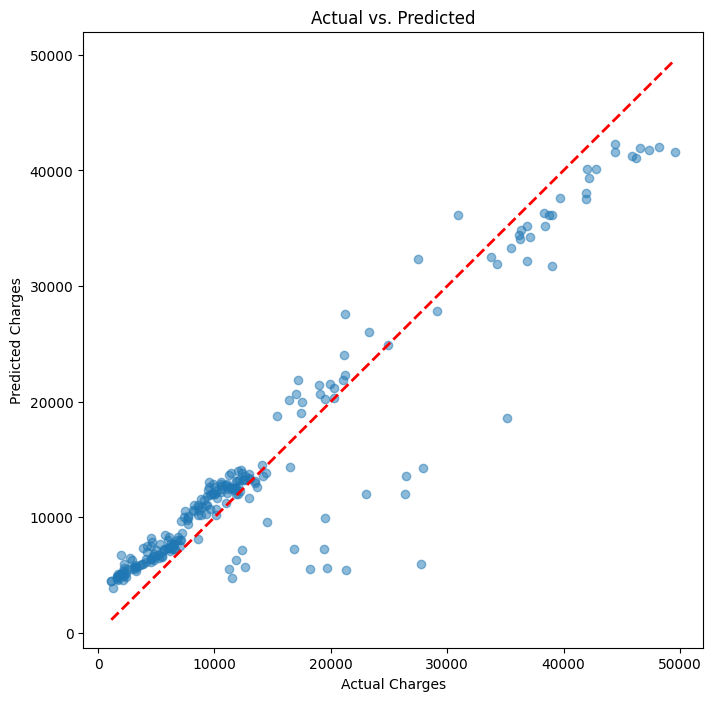

In [79]:
plt.figure(figsize=(8, 8))
plt.scatter(predictions_pd['charges'], predictions_pd['prediction'], alpha=0.5)
plt.plot([predictions_pd['charges'].min(), predictions_pd['charges'].max()],
         [predictions_pd['charges'].min(), predictions_pd['charges'].max()],
         'r--', lw=2)
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('Actual vs. Predicted')
plt.show()



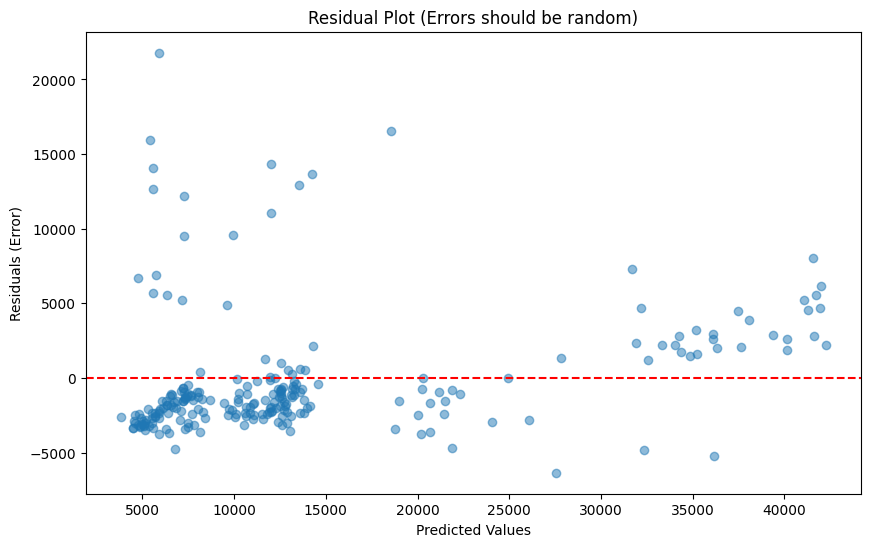

In [80]:
predictions_pd['residual'] = predictions_pd['charges'] - predictions_pd['prediction']

plt.figure(figsize=(10, 6))
plt.scatter(predictions_pd['prediction'], predictions_pd['residual'], alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals (Error)')
plt.title('Residual Plot')
plt.show()


In [84]:
### Gradient Boosted Trees

In [85]:
from pyspark.ml.regression import GBTRegressor

gbt = GBTRegressor(
    featuresCol="features",
    labelCol="charges",
    maxIter=150,
    maxDepth=8
)

gbt_model = gbt.fit(cleaned_train_dataset)

In [86]:
gbt_model

GBTRegressionModel: uid=GBTRegressor_a25081efab63, numTrees=150, numFeatures=8

In [87]:
gbt_evaluation=rf_model.transform(cleaned_test_dataset)

In [103]:
gbt_values=gbt_evaluation.select('charges','prediction').toPandas()

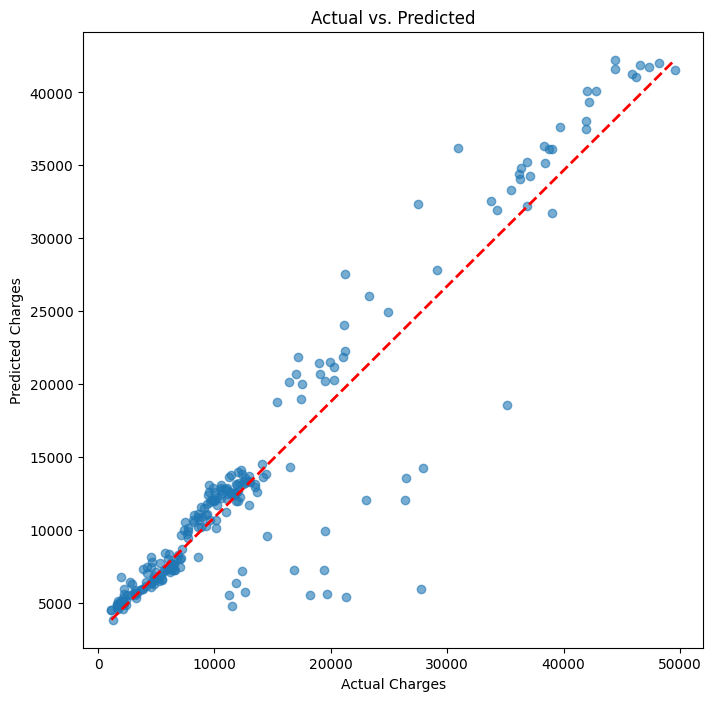

In [112]:
plt.figure(figsize=(8,8))
plt.scatter(gbt_values['charges'],gbt_values['prediction'],alpha=0.6)
plt.plot([gbt_values['charges'].min(),gbt_values['charges'].max()],
          [gbt_values['prediction'].min(),gbt_values['prediction'].max()],
         'r--',lw=2
)
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('Actual vs. Predicted')
plt.show()


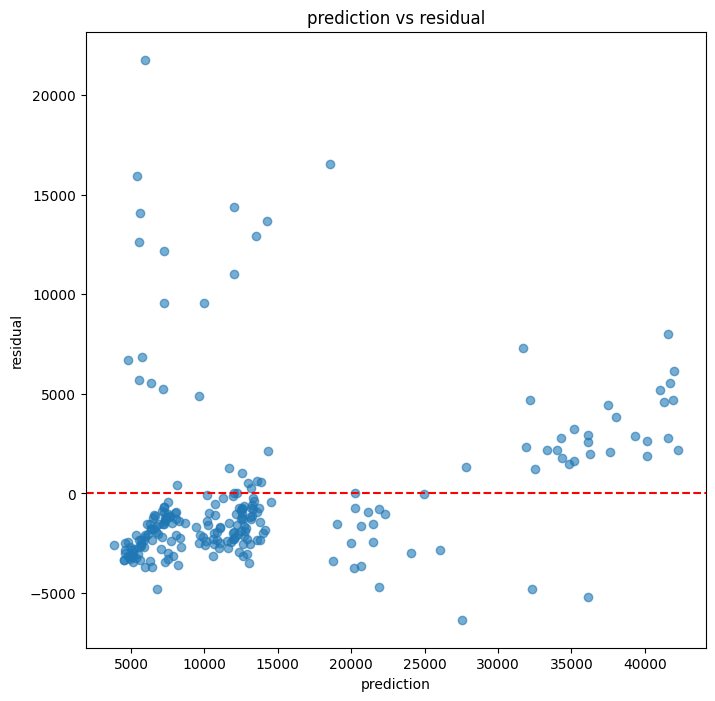

In [116]:
gbt_values['residual']=gbt_values['charges']-gbt_values['prediction']
plt.figure(figsize=(8,8))
plt.scatter(gbt_values['prediction'],gbt_values['residual'],alpha=0.6)
plt.axhline(y=0,color='r',linestyle='--')
plt.xlabel('prediction')
plt.ylabel('residual')
plt.title('prediction vs residual')
plt.show()

In [118]:
from pyspark.ml.evaluation import RegressionEvaluator
gbt_evaluator=RegressionEvaluator(
    labelCol='charges',
    predictionCol='prediction',
    metricName='rmse'

)
rmse=gbt_evaluator.evaluate(gbt_evaluation)

In [119]:
rmse

4128.623788316584